In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import jarque_bera

In [54]:

data = yf.download("CL=F",start='2021-01-01')





[*********************100%***********************]  1 of 1 completed


In [55]:

data.columns = [ d[0] for d in data.columns]



In [56]:
data['returns'] = ( data['Close']- data['Close'].shift(1) ) /  data['Close'].shift(1) *100

In [63]:
data.dropna(inplace=True)
data.reset_index(inplace=True)

In [69]:
data['weekdays'] =data['Date'].dt.day_of_week
data['weekdays'] =data['Date'].dt.day_name()

In [70]:
data

,Date,Close,High,Low,Open,Volume,returns,weekdays
0,2021-01-05,49.930000,50.200001,47.240002,47.380001,643191,4.850906,Tuesday
1,2021-01-06,50.630001,50.939999,49.480000,49.820000,509365,1.401964,Wednesday
2,2021-01-07,50.830002,51.279999,50.389999,50.529999,369292,0.395024,Thursday
3,2021-01-08,52.240002,52.750000,50.810001,50.930000,499416,2.773952,Friday
4,2021-01-11,52.250000,52.700001,51.500000,52.580002,394822,0.019139,Monday
...,...,...,...,...,...,...,...,...
1420,2026-08-28,83.400002,83.779999,82.250000,83.669998,167615,-0.155629,Friday
1421,2026-08-31,85.760002,86.790001,84.110001,84.690002,235761,2.829737,Monday
1422,2026-09-01,90.220001,90.970001,86.129997,86.309998,331106,5.200559,Tuesday
1423,2026-09-02,91.010002,92.290001,88.970001,90.650002,331106,0.875638,Wednesday


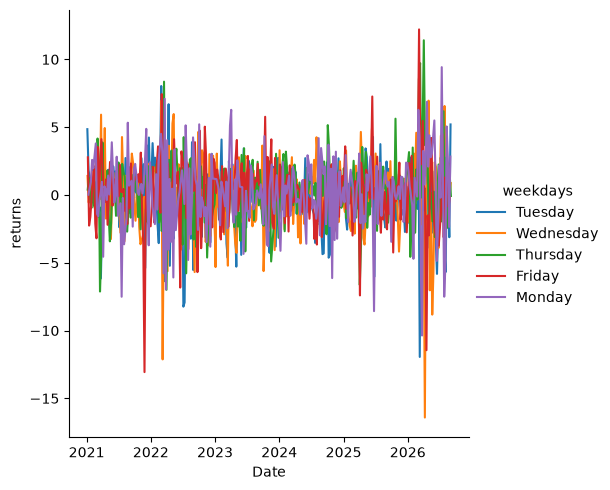

In [78]:
sns.relplot(data,x="Date",y='returns',kind='line',hue='weekdays')

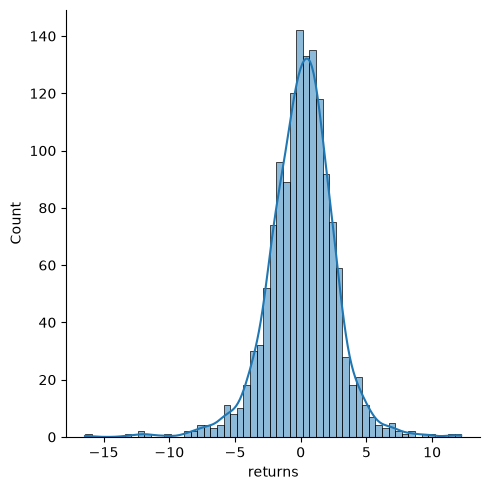

In [87]:
sns.displot(data,x='returns',kde=True)

In [89]:
jarque_bera(data['returns'])

SignificanceResult(statistic=np.float64(911.6752354786171), pvalue=np.float64(1.0770552249551338e-198))

In [84]:
data.groupby('weekdays')['returns'].agg(['mean','median'])

,mean,median
weekdays,,
Friday,0.174792,0.295980
Monday,0.179584,0.329130
Thursday,0.203016,0.202819
Tuesday,-0.132307,0.000000
Wednesday,-0.018800,0.197935


In [90]:
adfuller(data['returns'])

(np.float64(-8.937177099173576),
 np.float64(9.465015348686707e-15),
 15,
 1409,
 {'1%': np.float64(-3.434999576596685),
  '5%': np.float64(-2.8635934599975106),
  '10%': np.float64(-2.5678632530961614)},
 np.float64(6585.246877778893))

In [91]:
kpss(data['returns'])

C:\Users\Bullet\AppData\Local\Temp\ipykernel_26064\4084071945.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss(data['returns'])


(np.float64(0.11092232759977835),
 np.float64(0.1),
 4,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [95]:
data['dif_lag_1'] = data['Close'] - data['Close'].shift(1)

In [97]:
data.dropna(inplace=True)

In [98]:
data

,Date,Close,High,Low,Open,Volume,returns,weekdays,dif_lag_1
1,2021-01-06,50.630001,50.939999,49.480000,49.820000,509365,1.401964,Wednesday,0.700001
2,2021-01-07,50.830002,51.279999,50.389999,50.529999,369292,0.395024,Thursday,0.200001
3,2021-01-08,52.240002,52.750000,50.810001,50.930000,499416,2.773952,Friday,1.410000
4,2021-01-11,52.250000,52.700001,51.500000,52.580002,394822,0.019139,Monday,0.009998
5,2021-01-12,53.209999,53.450001,52.070000,52.180000,400200,1.837319,Tuesday,0.959999
...,...,...,...,...,...,...,...,...,...
1420,2026-08-28,83.400002,83.779999,82.250000,83.669998,167615,-0.155629,Friday,-0.129997
1421,2026-08-31,85.760002,86.790001,84.110001,84.690002,235761,2.829737,Monday,2.360001
1422,2026-09-01,90.220001,90.970001,86.129997,86.309998,331106,5.200559,Tuesday,4.459999
1423,2026-09-02,91.010002,92.290001,88.970001,90.650002,331106,0.875638,Wednesday,0.790001


In [116]:
data['months'] = data['Date'].dt.month_name()

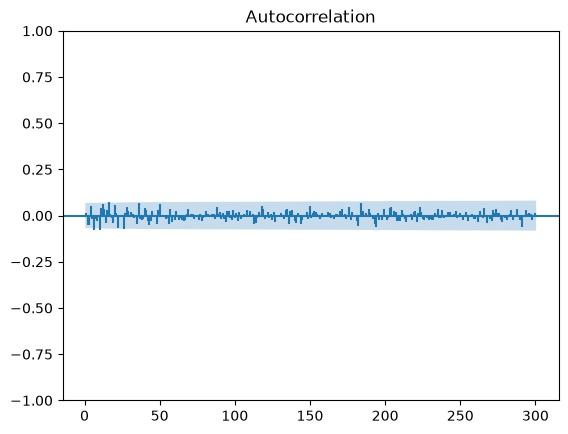

In [ ]:

plot_acf(data['returns'],lags=300,zero=False,marker="",alpha=0.01) # 1 % conf int 

plt.show()

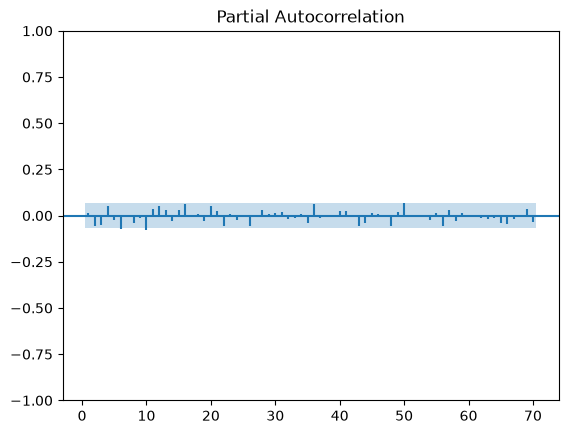

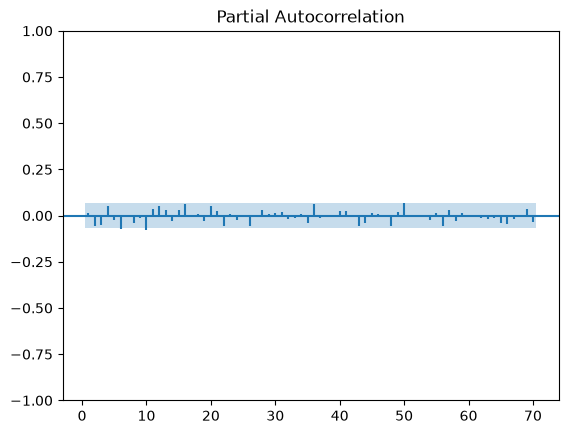

In [115]:
plot_pacf(data['returns'],lags=70,zero=False,marker="",alpha=0.01) # 1 % conf int 


In [121]:
data.groupby('months')['returns'].agg(['mean','median'])

,mean,median
months,,
April,0.012869,0.321740
August,-0.183841,-0.156735
December,0.111433,0.044320
February,0.228593,0.410805
January,0.337357,0.464035
July,0.266928,0.222899
June,-0.005527,0.302342
March,0.443856,0.360416
May,-0.120373,-0.014018
